# Liver Disease Dataset - Machine Learning Pipeline
This notebook handles preprocessing, imputing missing values, model training, evaluation, and saves the best model pipeline for production deployment.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report


## 1. Data Validation & Loading

In [2]:
DATA_PATH = '../datasets/liver/Liver Patient Dataset (LPD)_train.csv'

print(f"Loading dataset from: {DATA_PATH}")
# The dataset contains special characters like non-breaking spaces ( ) in columns, 
# so 'latin1' encoding is required to read it properly.
df = pd.read_csv(DATA_PATH, encoding='latin1')

# Clean column names by stripping leading/trailing whitespace and non-breaking spaces
df.columns = df.columns.str.strip().str.replace(u'\xa0', u'')

print(f"Dataset shape: {df.shape}")

TARGET = 'Result'

# Verify target exists
assert TARGET in df.columns, f"Target column '{TARGET}' not found in the dataset!"

# The target 'Result' contains values 1 and 2. 
# We map 1 -> 1 (Disease) and 2 -> 0 (No Disease) for standard binary classification.
df[TARGET] = df[TARGET].map({1: 1, 2: 0})
print(f"Target mapped: {df[TARGET].value_counts().to_dict()}")

df.head()


Loading dataset from: ../datasets/liver/Liver Patient Dataset (LPD)_train.csv
Dataset shape: (30691, 11)
Target mapped: {1: 21917, 0: 8774}


,Age of the patient,Gender of the patient,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio,Result
0,65.0,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1
1,62.0,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62.0,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58.0,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1
4,72.0,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1


## 2. Missing Values Analysis & Imputation Strategy

Total overall missing values: 5425 (1.61%)


,Missing %
Gender of the patient,2.938972
Alkphos Alkaline Phosphotase,2.593594
Total Bilirubin,2.111368
Direct Bilirubin,1.827897
A/G Ratio Albumin and Globulin Ratio,1.821381
Sgpt Alamine Aminotransferase,1.752957
ALB Albumin,1.609592
Total Protiens,1.508586
Sgot Aspartate Aminotransferase,1.505327
Age of the patient,0.006517


C:\Users\hp\AppData\Local\Temp\ipykernel_4460\1373443136.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df.index, y=missing_df['Missing %'], palette='Reds_r')


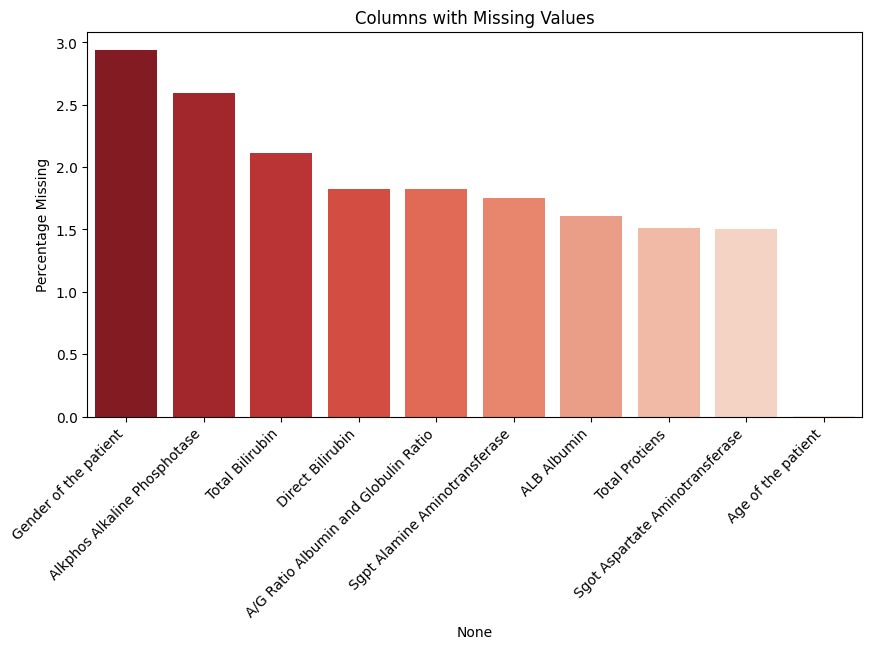

In [3]:
# Calculate missing percentages
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = missing_percent[missing_percent > 0].sort_values(ascending=False).to_frame(name='Missing %')

print(f"Total overall missing values: {df.isnull().sum().sum()} ({(df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.2f}%)")
display(missing_df)

if len(missing_df) > 0:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing_df.index, y=missing_df['Missing %'], palette='Reds_r')
    plt.xticks(rotation=45, ha='right')
    plt.title('Columns with Missing Values')
    plt.ylabel('Percentage Missing')
    plt.show()


## 3. Train-Test Split & Features Identification

In [4]:
# Separate features and target
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

# Automatically identify categorical and numerical features
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")


Train set: (24552, 10), Test set: (6139, 10)
Numerical features (9): ['Age of the patient', 'Total Bilirubin', 'Direct Bilirubin', 'Alkphos Alkaline Phosphotase', 'Sgpt Alamine Aminotransferase', 'Sgot Aspartate Aminotransferase', 'Total Protiens', 'ALB Albumin', 'A/G Ratio Albumin and Globulin Ratio']
Categorical features (1): ['Gender of the patient']


C:\Users\hp\AppData\Local\Temp\ipykernel_4460\3080198706.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()


## 4. Preprocessing Pipeline

In [5]:
# Production-ready Preprocessing
# We use SimpleImputer for missing values before scaling/encoding
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Fitting preprocessor...")
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)
print(f"Transformed train shape: {X_train_preprocessed.shape}")
print("Preprocessing complete!")


Fitting preprocessor...
Transformed train shape: (24552, 11)
Preprocessing complete!


## 5. Model Training

In [6]:
# Initialize models optimized for deployment
# We use class_weight='balanced' where applicable to handle imbalanced target
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced'),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1, scale_pos_weight=scale_pos_weight)
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_preprocessed, y_train)
    trained_models[name] = model
print("Training complete!")


Training Logistic Regression...
Training Random Forest...


c:\Users\hp\django\MediSense\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Training XGBoost...
Training complete!


c:\Users\hp\django\MediSense\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:30:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 6. Evaluation & Confusion Matrices

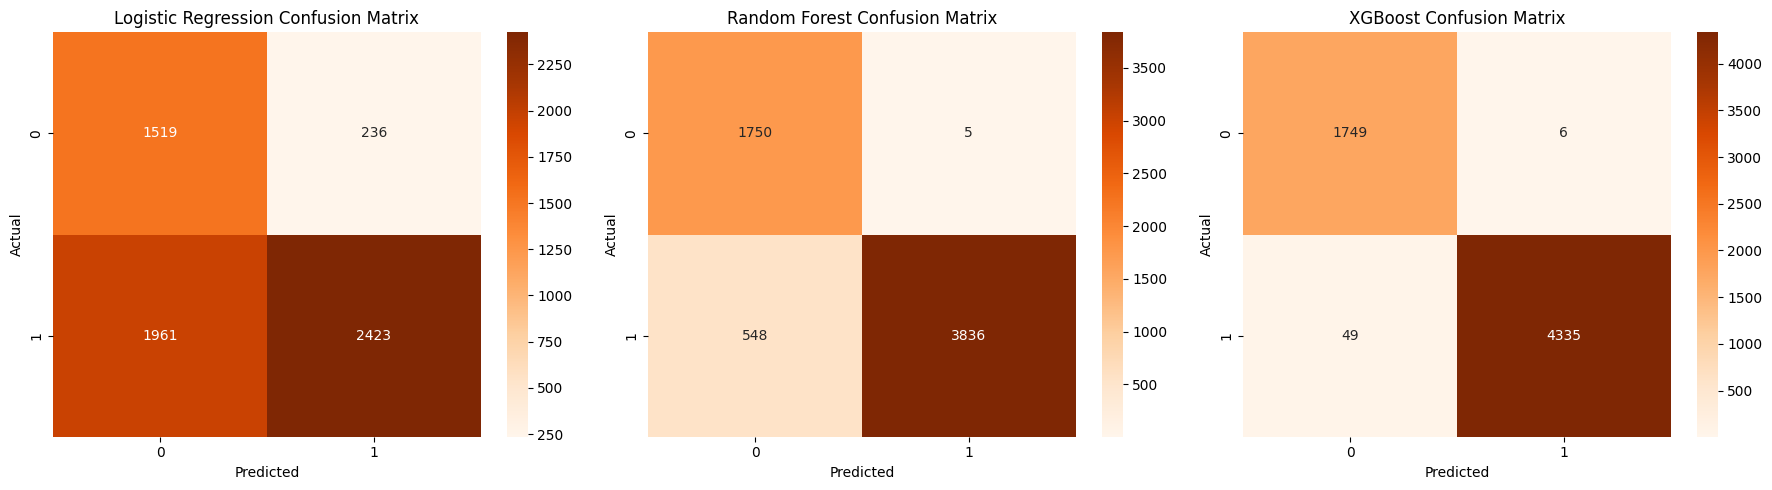

In [7]:
results = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_preprocessed)
    y_prob = model.predict_proba(X_test_preprocessed)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    })
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()


## 7. Model Comparison & Best Model Selection

In [8]:
# Create comparison report
results_df = pd.DataFrame(results).set_index('Model')
print("Model Comparison Report:")
display(results_df)

# Select best model based on ROC AUC
best_model_name = results_df['ROC AUC'].idxmax()
best_model = trained_models[best_model_name]
print(f"\nBest Model selected based on ROC AUC: **{best_model_name}**")


Model Comparison Report:


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.642124,0.911245,0.552692,0.688059,0.761521
Random Forest,0.909920,0.998698,0.875000,0.932766,0.998437
XGBoost,0.991041,0.998618,0.988823,0.993696,0.999280



Best Model selected based on ROC AUC: **XGBoost**


## 8. Save Best Model Pipeline

In [9]:
# Bundle preprocessor and best model into a single deployable artifact
os.makedirs('../models', exist_ok=True)
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

model_path = '../models/liver_model.pkl'
joblib.dump(full_pipeline, model_path)
print(f"Successfully saved complete {best_model_name} pipeline to {model_path}")


Successfully saved complete XGBoost pipeline to ../models/liver_model.pkl


## 9. Feature Importance Analysis

C:\Users\hp\AppData\Local\Temp\ipykernel_4460\3676370513.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='plasma')


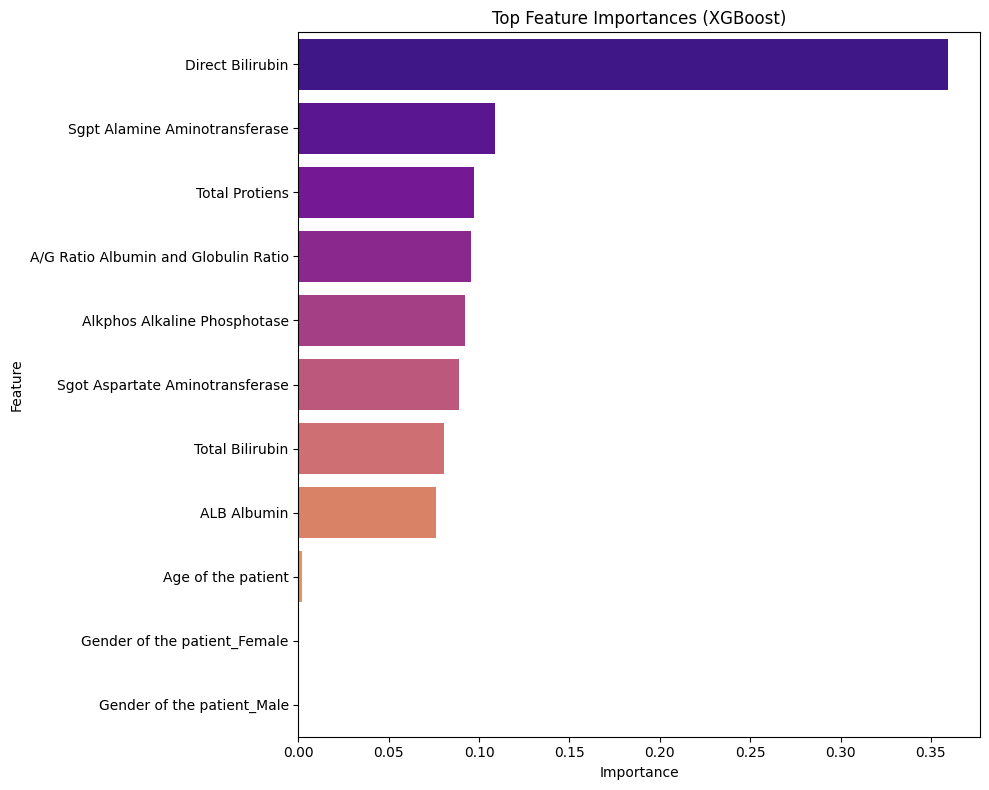

In [10]:
# Extract feature names from OneHotEncoder
if categorical_features:
    cat_features_out = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features)
    feature_names = numerical_features + list(cat_features_out)
else:
    feature_names = numerical_features

if best_model_name == 'Logistic Regression':
    importances = np.abs(best_model.coef_[0])
else:
    importances = best_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='plasma')
plt.title(f'Top Feature Importances ({best_model_name})')
plt.tight_layout()
plt.show()
